# Monte Carlo of the Ising Model
This notebook will be dedicated to the solving of the Ising model via Markov Chain Monte Carlo method. I will then look at and compare solving the model with Machine Learning methods either in this notebook or a separate notebook. Inspiration for this notebook including the [Illinois Computing in Physics course](https://courses.physics.illinois.edu/PHYS446/sp2023/Ising/IsingModel.html), a blog post by [Tanya Schlusser](https://tanyaschlusser.github.io/posts/mcmc-and-the-ising-model/) and some theory from Richard Fitzpatrick's [lecture notes](https://farside.ph.utexas.edu/teaching/329/lectures/node110.html).

## ToDo
- Rerwite algorithm in C++ to improve speed and interface with Python for visualisation
- Renormalisation group calculation
- Parallelisation
- Machine learning

## The Ising model
First, we will review the Ising model. The Ising Hamiltonian is
$$
H = -\sum_{<ij>}J_{ij}S_{i}S_{j}-\sum_{i}BS_{i}.
$$
This Hamiltonian describes a collection of localised classical degrees of freedom, often chosen to represent magnetic moments or spins of atoms on a lattice with sites $i=1,2,\cdots, N$. However, it could also represent pixels in an image or nodes in a neural network. Considering the lattice of atoms system we choose the spins to point in one of two directions $S_i= \pm 1$, up or down. Each spin couples to an external magnetic field $B$ so that the orientation $S_i=+1$ is favoured. The sum runs over nearest neighbour sites $<ij>$. Hence, pairs of spins interact via a magnetic coupling $J_{ij}$ between the different lattice sites. For $J>0$ ($J<0$) the interactions are ferromagnetic (antiferromagnetic), aligned (anti-aligned) spins are favoured. 

The Ising model is one of the simplest models exhibiting spontaneous symmetry breaking. In the absence of a field $B=0$ the total energy of the system is invariant under up-down symmetry or a change of variables $S_i \rightarrow -S_i$. However, (for $d \geq 2$) as temperature is lowered the system favours the alignment of all spins into one of these states breaking the up-down symmetry and inducing a non-zero order parameter, the magnetisation $m=1/N\sum_i\langle S_i \rangle$. This behaviour occurs only in the thermodynamic limit, $N\rightarrow \infty$. Hence, a challenge for solving this system with Monte Carlo and or ML is in the finite-size scaling needed to extrapolate $N$ simulations. 

There are analytical solutions to the system for $d \leq 2$ cases. For example, on a square lattice for nearest-neighbour ferromagnetic coupling and in zero field, it undergoes a second-order transition between paramagnetic ($m=0$) and ferromagnetic ($m\neq0$) phases at $T_c = 2.269 J$. The correlation length $\xi \sim 1/(T-T_c)^\nu$ and the magnetic susceptibility $\chi = [\langle m^2 \rangle - \langle m \rangle^2]/T\sim 1/(T-T_c)^\gamma$ diverge at the transition. The exponents $\nu=1$ and $\gamma = 7/4$ are known analytically, as is the exponent $\beta = 1/8$ describing the onset of the magnetization $m\sim (T_c-T)^\beta$. 

However, there is no known analytical solution for $d>2$. Hence, the need for Markov chain Monte Carlo methods.

## Markov Chain Monte Carlo
Now we introduce the Markov Chain Monte Carlo method. These are a class of algorithms used for simulating physical systems in condense matter physics. The techniques perform a random walk through some configuration space while statistically sampling the relevant observables in a way that guarantees the correct probability distribution is generated. 

## Classical Monte Carlo
In a classical Monte Carlo simulation, one aims to evaluate the thermodynamic expectation value of an observable $O$ with respect to a set of microstates $|m\rangle$ that follow a Boltzmann probability distribution,
$$
\langle O \rangle = {1}/{Z}\sum_m \langle m | O_m e^{-\beta E_m} | m \rangle 
$$
where $E_m$ is the energy of the microstate, $\beta = 1/kT$ with $k$ the Boltzmann's constant, $O_m$ denotes the value of the observable for the microstate and $Z=\sum_m \exp{(-\beta E_m)}$. The sum must be taken of all microstates which is intractable for most systems of interesting. So we must use the Markov Chain monte Carlo methods. 

For a classical system in contact with a energy reservoir of temperature $T$, the probability of finding the system in a specific microstate (or configuration) $m$ is given by 
$$
P(m) = e^{-\beta E_m} / Z.
$$
The goal of markov chain Monte Carlo is to give us these microstates $m$ with this probability $P(m)$.


## Markov Chain
A markov chain is a process where you are at some microstate (or configuration) $m$ and then you choose another state $m'$ with a probability that only depends on the current state $m$. It is a memory-less process that is independent of the history of previous configurations that the system may have been on. That is $P(m\rightarrow m')$ is independent of some previous configuration $l$. 

As long as we do a non-pathological random walk in a memory-less way, we guarantee that after walking around enough the probability we are in configuration $m$ is some $\pi(m)$. $\pi$ is called a stationary distribution. Different markov chains have different stationary distributions. 

A markov chain is non-pathological if:
- It is *aperiodic*: it doesn't cycle between configurations in a subset of the system's full configuration space. 
- It is *connected*: given two configurations, there is a path with non-zero probability that the chain could follow to from one to the other.

To simulate the Ising model, we want to build a markov chain with the stationary distribution $\pi(m) \sim e^{-\beta E_m}$. This can be done with a famous algorithm.



## Metropolis-Hasting Algorithm
If you know your desired stationary distribution, the Metropolis-Hastings algorithm provides a canonical way to generate a Markov chain that produces this distribution. 
The general steps of the algorithm are:
1. Start with some configuration (microstate) $m$
2. Propose a move to a new trial configuration $m'$ with a transition probability $T(m\rightarrow m')$
3. Accept the move to $m'$ with probability $$\text{min}\left( 1, \dfrac{\pi(m')}{\pi(m)}\dfrac{T(m'\rightarrow m)}{T(m\rightarrow m')} \right)$$

The most important part of Markov Chain Monte Carlo is the procedure we choose for movement between configurations. In the simplest implementations of the Metropolis algorithm, we choose a movement procedure where forward and reverse moves are equally probable $T(m\rightarrow m') = T(m' \rightarrow m)$. This has useful implications we see below. 

To incorporate the desired distribution $\pi$ and ensure the Markov chain asymptotes to the desired distribution, the metropolis algorithm uses an acceptance ratio:
$$\alpha \equiv \dfrac{\pi(m')}{\pi(m)}\dfrac{T(m'\rightarrow m)}{T(m\rightarrow m')}.$$

If we have equally likely forward and reverse moves $T(m\rightarrow m') = T(m' \rightarrow m)$, the acceptance criteria simplifies to the relative probability of the two configurations $m'$ and $m$. Then if $\alpha > 1$, $m'$ is more likely than $m$ and we accept the move with probability 1. When $\alpha < 1$, $m'$ is less likely than $m$ and the proposed move is accepted with probability $\alpha$. This last acceptance ensures that the Markov Chain follows the desired distribution $\pi(m)$. In the case of the Ising model this is the Boltzmann distribution.

So for the Ising model the acceptance criterion becomes 
$$\alpha \equiv {\displaystyle \frac{\pi(m')}{\pi(m)}} = \frac{e^{-\beta E_{m'}} / Z}{e^{-\beta E_m} / Z} = \dfrac{e^{-\beta E_{m'}}}{e^{-\beta E_m}} = e^{-\beta \Delta E}$$
where $\Delta E = E_{m'} - E_{m}$. This is assuming that we have forward and backward moves occurring with equal probabilities. That is we must choose new configurations randomly or with a certain pattern that ensures equally likely transitions from $m$ to $m'$.


For the Ising model, we start with a random lattice of up or down spins, the initial condition. The Metropolis-Hasting algorithm will then perform the following operations at each "step":
1. Select a new configuration $m'$ with some probability $p(m'\rightarrow m)$, given the current configuration $m$. The simplest option is to choose a random spin and flip it, which has $T(m\rightarrow m') = T(m'\rightarrow m)=1/N$ where $N$ is the number of spins. This ensures that the ratios of $T$ cancel in $\alpha$.
2. Calculate the change in energy $\Delta E = E_{m'} - E_{m}$ from changing configurations (a single spin flip).
3. The proposed move is accepted with probability $p=\text{min}(1, e^{-\beta\Delta E})$ where $\beta = 1/T$ is the inverse temperature in units $k_B=1$.

We will call a sweep doing $N$ of these steps. Typically, a certain number of sweeps will need to be performed before collecting data to ensure that the Markov Chain forgets the initial condition and reaches an equilibrium. Measurements of observables can then be preformed every sweep. These measurements sampled at each sweep will build our probability distribution for each temperature, from which we can determine the expectation value of an observable and its error.

# Creating our own Markov Chain Monte Carlo of the Ising model
First import the required packages.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import emcee

We will use the metropolis-hastings algorithm on the Ising model of a 2D lattice. We will consider the case with no external magnetic field $B=0$ and assume that $J_{ij} = J$ is the same for all spin interactions.
To create a random initial of our 2D lattice of up or down spins we can do the following in Python:


In [3]:
height = 10
width = 10
lattice = np.random.choice([-1,1], size=(height, width))
print(lattice)

[[ 1 -1  1  1 -1 -1 -1 -1  1  1]
 [ 1  1 -1 -1  1  1  1 -1 -1 -1]
 [-1 -1  1 -1  1  1 -1 -1 -1 -1]
 [ 1  1 -1  1  1  1  1  1 -1  1]
 [-1 -1 -1 -1 -1 -1 -1 -1  1  1]
 [-1 -1  1  1 -1  1 -1  1  1  1]
 [-1 -1 -1 -1 -1  1 -1 -1 -1 -1]
 [ 1 -1 -1  1 -1 -1 -1  1  1  1]
 [-1  1 -1 -1  1 -1  1  1  1 -1]
 [-1 -1  1 -1 -1 -1  1 -1 -1 -1]]


## Setting up our energy calculations
At each step we flip the spin, calculate the change in energy and determine which case is more energetically favourable. 

We determine this from a probability $p=\text{min}(1, e^{-\beta\Delta E})$. That is:
- if $\Delta E \geq 0$, accept with probability $p=1$ 
- if $\Delta E > 0$ accept with probability $p=e^{-\beta\Delta E}$. 
So if the energy of the system decreases we definitely accept. If the energy change is positive we only accept according to the Boltzmann probability distribution.


To calculate the energy difference at each step we could calculate the energy of the whole system with and without the flipped spin. The energy of the system for no external field $B=0$ is
$$
    E = -J\sum_{<ij>}S_iS_j
$$
where $\sum_{<ij>}$ is a sum over all the nearest neighbours in the system and we are assuming that $J$ is constant for all nearest neighbour interactions. In order, to calculate the energy at each site we need to consider that there are four nearest neighbours of each site, except obviously the sites on the edge. We can get around this by using periodic boundary conditions on the edge of the lattice. 

If we want to calculate the energy difference we have to compute this energy twice and subtract. Computationally, this requires looping through each lattice site and its nearest neighbours which has an order $\mathcal{O}(N+B)$ where $N$ is the number of spins and $B$ is the number of nearest neighbour bonds at each site. This becomes very inefficient for large $N$ systems. There is a simpler way to calculate the energy difference $\Delta E$ which has $\mathcal{O}(1)$.

At any given site in the lattice, the energy of that site is given by:
$$
E_{i} = -J S_{i}\sum_{j\in\text{nn}(i)}S_{j}
$$
where $j$ iterates over the four nearest neighbours of $i$.

In the flipping of a spin at site $i$, $E_{i}$ is the only thing that changes in the total energy of the system $E$. You may wonder about the energy at neighbouring sites but this is already considered in $E_{i}$. The sum over nearest neighbours in $E$ ensures that it counts the interactions between each spin pair once by including a factor of a half. That is the sum $\sum_{<ij>}= \frac{1}{2}\sum_i \sum_{j\in\text{nn}(i)}$. Since we are only counting each spin pair interaction once in $E_{i}$ we do not need a factor of a half. Hence, the energy difference from flipping the spin at a sight is given by:
$$
\Delta E = E_{i, \text{flipped}} - E_{i, \text{current}} = -J \sum_{j\in\text{nn}(i)}S_{j} (S_{i, \text{flipped}}-S_{i, \text{current}}) = 2JS_{i, \text{current}}\sum_{j\in\text{nn}(i)}S_{j}
$$
where the last equality is because $S_{i, \text{flipped}} = -S_{i, \text{current}}$. This calculation is independent of the size of the system $N$ and only requires summing over the nearest neighbours which is a constant $B=4$, hence we have $\mathcal{O}(1).

Let us define a function to calculate $\Delta E$. Here we use the dimensionless case and absorb $J$ into the temperature $\tilde{T} = kT/J$

In [4]:
def deltaE(spins, spin_to_flip):
    i, j = spin_to_flip
    height, width = spins.shape
    nn_sum = 0
    for di, dj in ((1, 0), (0, 1), (-1, 0), (0, -1)):
        # find nearest neighbours with periodic boundary conditions
        ii = (i + di) % height 
        jj = (j + dj) % width
        nn_sum += spins[ii, jj]
    return 2 * spins[i, j] * nn_sum # the flipped spin energy subtract the current spin energy
    

While we are at it let's create a function to determine the total energy of the lattice $E$. Then we can check that our `deltaE` function outputs the same energy as calculating the total energy of the lattice $E$ before and after a spin flip and subtracting. 

In [5]:
def getEnergy(spins):
    height, width = spins.shape
    total_energy = 0
    # loop through each site and sum the energy of each site
    for i in range(height):
        for j in range(width):
            nn_sum = 0
            for di, dj in ((1, 0), (0, 1), (-1, 0), (0, -1)):
                 # find nn with periodic boundary conditions
                ii = (i + di) % height 
                jj = (j + dj) % width
                nn_sum += spins[ii, jj]
            total_energy += - (1 / 2) * spins[i, j] * nn_sum # factor of 1/2 to avoid double counting nn interactions
    return total_energy

Let us calculate $\Delta E$ of a random spin flip in a 3 by 3 lattice using the `deltaE` function and the `get_energy` function. We will compare the computation times and the final answer.

In [6]:
import time

L = 10
spins =  np.random.choice([1, -1], (L, L))
spin_to_flip = np.random.choice(np.arange(L), (2)).tolist()
print('Consider the 2D square lattice:')
print(spins)
print('We propose a spin flip at')
print(spin_to_flip)

start_time = time.perf_counter()
dE_output = deltaE(spins, spin_to_flip)
end_time = time.perf_counter()
dE_elapsed_time = end_time - start_time

print(f'Calculating deltaE with the deltaE function gives {dE_output} in a time of {dE_elapsed_time} seconds.')

start_time = time.perf_counter()
E_current = getEnergy(spins)
spins[spin_to_flip[0], spin_to_flip[1]] = - spins[spin_to_flip[0], spin_to_flip[1]]
E_flipped = getEnergy(spins)
getE_output = E_flipped - E_current
end_time = time.perf_counter()
getE_elapsed_time = end_time - start_time

print(f'Calculating deltaE with the get_energy function gives {getE_output} in a time of {getE_elapsed_time} seconds.')

Consider the 2D square lattice:
[[-1  1  1  1 -1 -1 -1  1 -1 -1]
 [-1 -1 -1  1 -1 -1 -1 -1  1 -1]
 [ 1 -1  1 -1 -1  1  1 -1  1 -1]
 [ 1  1  1 -1 -1 -1 -1  1  1  1]
 [ 1 -1 -1  1  1 -1  1  1 -1  1]
 [-1  1 -1  1  1 -1 -1  1 -1 -1]
 [-1  1  1  1 -1 -1  1 -1 -1  1]
 [ 1  1 -1  1 -1 -1  1  1  1  1]
 [-1  1 -1 -1 -1  1 -1 -1 -1  1]
 [-1 -1  1 -1 -1 -1 -1  1  1  1]]
We propose a spin flip at
[8, 4]
Calculating deltaE with the deltaE function gives 4 in a time of 3.391700010979548e-05 seconds.
Calculating deltaE with the get_energy function gives 4.0 in a time of 0.00045183400015957886 seconds.


We can see that the `deltaE` function is clearly faster than the `get_energy` function and this difference becomes clearer with larger $L$. We can mess around with $L$ variable to see this. Running the code multiple times we also see that the results of the two calculations agree consistently. 

# Building the Metropolis-Hasting Algorithm 


Now that we have validated our calculation of $\Delta E$ we can move on to building the rest of the Metropolis-Hastings algorithm. Our Markov Chain Monte Carlo will start with an initial random lattice and then perform a large number of sweeps consisting of $N$ steps. In each step we will perform the Metropolis-Hastings algorithm. We select a new configuration, calculate $\Delta E$ and accept or reject the new configuration. Now how do we choose the new configurations? Previously we mentioned that randomly selecting a spin to flip makes the most sense to cancel out the transition probabilities $T$ in the acceptance criterion $\alpha$. However, a lot of people including [Tanya Schlusser](https://tanyaschlusser.github.io/posts/mcmc-and-the-ising-model/) step through the lattice sequentially to choose a new configuration. They argue that this is to ensure that each site in the lattice is seen.

From above we expect that stepping through sequentially will mean that the transition probability of a going from a configuration to another is not equal to the reverse transition. That is we are favouring transitions of the next spin in the lattice rather than an equal probability of flipping a spin before or after a given spin. This would suggest that detailed balance is not satisfied. A [AIP paper](https://pubs.aip.org/aip/jcp/article/124/6/064109/903861/Acceleration-of-Markov-chain-Monte-Carlo) suggests that detailed balance is not necessary for convergence of a Markov chain Monte Carlo simulations and can lead to faster convergence. I am interested to see if this is indeed the case. I will write two versions of the algorithm one that choose spins to flip sequentially and one that chooses them randomly. We can then compare results.

## Sequential stepping through the lattice
Let's try stepping through the lattice sequentially first, as  does because then we know we will visit each site. 


Visualisation setup from [Tanya Schlusser](https://tanyaschlusser.github.io/posts/mcmc-and-the-ising-model/).

In [7]:
from array2gif import write_gif

rng = np.random.default_rng(42)

def to_two_color(lattice):
    blue = np.ones(lattice.shape, dtype=int) * 255 
    red = np.zeros(lattice.shape, dtype=int)
    red[lattice < 0] = 255 
    green = red 
    return np.array([red, green, blue])


def output_to_gif(dataset, filename, fps=8):
    print("Frames: {}".format(len(dataset)))
    colors = []
    write_gif(
        [to_two_color(lattice) for lattice in dataset],
        filename,
        fps=fps
    )

In [8]:
def markovChainSequential(spins, T, num_sweeps=100, output=True):
    height, width = spins.shape
    snapshots = []
    snapshots.append(to_two_color(spins))
    magnetization = []
    for sweep in range(num_sweeps):
        
        if (sweep % 5 == 0):
            snapshots.append(to_two_color(spins))
            
        for i in range(height):
            for j in range(width):
                dE = deltaE(spins, (i, j))
                if dE <= 0: # If energy decreases we accept the flip
                    spins[i,j] = - spins[i, j]
                elif np.random.random() < np.exp(-dE/T): # If energy increases, we accept the flip with probability of Boltzmann distribution
                    spins[i,j] = - spins[i, j]

        M = abs(spins.sum() / spins.size)
        magnetization.append(M)
        if output==True:
            print(f'Iteration {sweep+1} complete. Net magnetization: {M} \n')
    
    return snapshots, spins, magnetization


## Random selection of spin to flip
Let us now set up a version of the algorithm that randomly selects the spin to be flipped. 

In [9]:
def markovChainRandom(spins, T, N=100, num_sweeps=10000, output=False):
    height, width = spins.shape
    snapshots = []
    snapshots.append(to_two_color(spins))
    magnetization = []
    for sweep in range(0, num_sweeps):
        for step in range(0, N):
            randi = np.random.randint(0, height)
            randj = np.random.randint(0, width)
            dE = deltaE(spins, (randi, randj))
            if dE < 0:
                spins[randi, randj] = - spins[randi, randj]
            elif np.random.random() < np.exp(- dE / T): 
                spins[randi, randj] = - spins[randi, randj]
        
        M = abs(spins.sum() / spins.size)
        magnetization.append(M)

        if (sweep % 5 == 0):
            snapshots.append(to_two_color(spins))

        if output==True:
            print(f'Iteration {sweep+1} complete.')
    
    return snapshots, spins, magnetization

## Comparing the sequential and random methods
Now let us run both markov chain algorithms. We will save gifs of the snapshots for both as well as the final state of each algorithm after 1000 iterations and the magnetisation recorded over the iterations. This will give us an idea of which algorithm converges first and whether the resultant state is as expected.

In [10]:
def runMarkovChain(T_over_Tc=0.9, height=10, width=10, num_sweeps=100, algorithm='random', output_prog=True, output_gif=False):
    Tc = 2.269 # Normalized T:= kT/J
    T = T_over_Tc * Tc
    lattice = np.random.choice([-1,1], (height, width))
    if algorithm=='random':
        dataset, final_state, magnetization = markovChainRandom(lattice, T, N=height*width , num_sweeps=num_sweeps, output=output_prog)
    elif algorithm=='sequential':
        dataset, final_state, magnetization = markovChainSequential(lattice, T, num_sweeps=num_sweeps, output=output_prog)

    if output_gif==True:
        filename = (f'./gifs/ising_{algorithm}_{T_over_Tc}_{height}x{width}_{num_sweeps}.gif')
        write_gif(dataset, filename, fps=8)
    return dataset, final_state, magnetization

In [12]:
T_over_Tc = 1.25
L = 100
num_sweeps = 3000
dataset_seq, final_state_seq, mag_seq = runMarkovChain(T_over_Tc, height=L, width=L, algorithm='sequential', num_sweeps=num_sweeps, output_gif=True, output_prog=False)
dataset_ran, final_state_ran, mag_ran = runMarkovChain(T_over_Tc, height=L, width=L, algorithm='random', num_sweeps=num_sweeps, output_gif=True, output_prog=False)

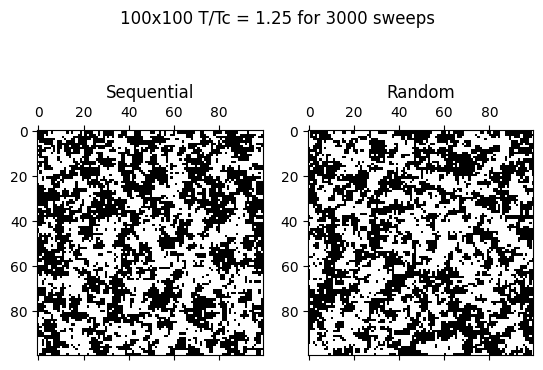

In [167]:
fig, ax = plt.subplots(1, 2)
fig.suptitle(f'{L}x{L} T/Tc = {T_over_Tc} for {num_sweeps} sweeps')
ax[0].matshow(final_state_seq, cmap='gray')
ax[1].matshow(final_state_ran, cmap='gray')
ax[0].set_title('Sequential')
ax[1].set_title('Random')

filename = f"./figures/compare_finalstate_seq_v_ran_{L}x{L}_{T_over_Tc}_for_{num_sweeps}.png"
fig.savefig(filename)

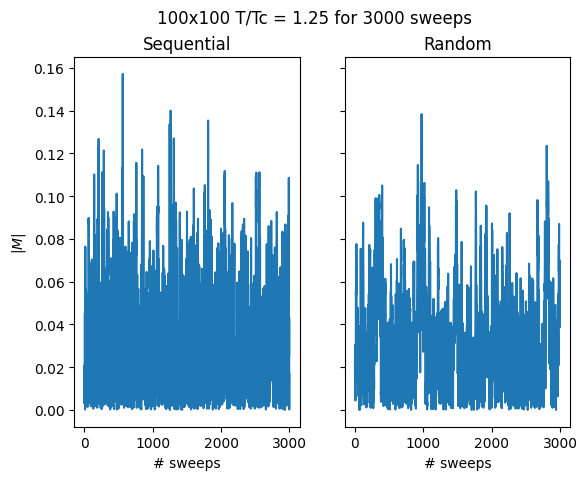

In [168]:
fig, ax = plt.subplots(1, 2, sharey=True)
fig.suptitle(f'{L}x{L} T/Tc = {T_over_Tc} for {num_sweeps} sweeps')
ax[0].plot(mag_seq)
ax[1].plot(mag_ran)
ax[0].set_title('Sequential')
ax[1].set_title('Random')
ax[0].set_ylabel(r'$|M|$')
ax[0].set_xlabel("# sweeps")
ax[1].set_xlabel("# sweeps")
# ax[0].set_xlim(-100, 3000)
# ax[1].set_xlim(-100, 3000)

filename = f"./figures/compare_mag_seq_v_ran_{L}x{L}_{T_over_Tc}_for_{num_sweeps}.png"
fig.savefig(filename)

Interestingly, the sequential model seems to converge to an ordered state much faster than the random model. In the 100 by 100 lattice case the random model takes almost 1000 to 2000 sweeps to converge, sometimes more because domain walls form and it is hard to break these. But the sequential case does not always beat the random case for large systems like the 100 by 100 lattice. In the examples above we have looked at the case when the temperature is set well below the critical temperature so it should converge. It looks as if the sequential approach is generally faster at least for smaller systems. However, I am unsure if it is still statistically accurate. The [AIP paper](https://pubs.aip.org/aip/jcp/article/124/6/064109/903861/Acceleration-of-Markov-chain-Monte-Carlo) suggests that sequential algorithm is acceptable to use however it does have its downfalls. In some cases the sequential algorithm will cycle between two states because of the reducibility of the sweep transition kernel. At high temperatures when the acceptance probability is 1, any initial state will repeat itself after $2k$ steps. The paper does propose its own sequential algorithm with skipping to get around this. However, this requires adding another implementation. I think that I am better off sticking with the random case which is statistically correct to avoid any potential cyclic behaviours. If more speed is needed to solve large lattice's there are computational improvements that can be made: flipping multiple non nearest neighbour spins, parallelisation and using a lower level language like C++.

## Measuring observables
Now that we see the algorithm works fairly well at solving the Ising model for a large number of iterations lets try and measure observables like magnetisation as a function of temperature. This requires creating a temperature array and running the Markov Chain Monte Carlo algorithm for each temperature. The markov chain monte carlo will measure observables for each sweep, these measurements will build up the approximation of our stationary distribution from which we can determine the expected value of the observable.

First recall that the average value of an observable $O$ is given by
$$
\langle O \rangle = \sum_m P_m O_m = \sum_m P_m \langle m|O|m \rangle
$$
where $m$ is a given microstate or configuration and $P_m$ is its corresponding probability. For our case the probability of a microstate is given by the Boltzmann distribution $P_m = 1/Z e^{-\beta E_m}$. Substituting this probability in we get the relation from earlier:
$$
\langle O \rangle = {1}/{Z}\sum_m \langle m | O_m e^{-\beta E_m} | m \rangle.
$$

For a given observable we can rewrite this as
$$
\langle O \rangle =\sum_O P(O) O
$$
were $P(O) = \sum_{m \ \text{with} \ O} P_m$ is the sum of the probabilities of all microstates that have a given value of the observable.

The idea of the Markov Chain Monte Carlo is to build this probability distribution $P(O)$ by sampling the observable at different microstates or configurations throughout the Markov Chain. This probability distribution can be plotted as a histogram and then used to determine the expectation value of the observable.

The observables we are interested in here are energy, magnetisation and specific heat capacity although we can calculate others like entropy or free energy if we desired.

The magnetisation is given by:
$$
    M = \mu \sum_{i=1}^{N}S_i = \mu N \bar{S}
$$
since we are considering the zero external field case the sign of the magnetisation is irrelevant and we just consider the absolute value or squared value here.

The energy is given by:
$$
    E = \sum_{i=1}^{N} e_i
$$
where 
$$
    e_i = -\frac{J}{2}\sum_{k=1}^{z}S_{k}S_i - \mu BS_i
$$
where $z$ is the number of nearest neighbours, 4 for the 2D lattice. So we calculate the energy at each site and then sum them all to determine the total energy.

The specific heat capacity is $C = dE/dT$. We can calculate this in two ways. The first is with a discrete derivative
$$
C = \lim_{\Delta T \rightarrow 0} \frac{\Delta E}{\Delta T}
$$
but this is difficult due to the statistical noise in the energy. The second option is to make use of a standard result in equilibrium statistical thermodynamics:
$$
C = \frac{\sigma_E^2}{kT^2}
$$
where $\sigma_E$ is the standard error of the expectation value of $E$.


We have already created a function for determining the energy of a system. Although I want to normalise this energy to the number of states in the system. Let's create a function for determining the normalised energy and the magnetisation squared. We will do the specific heat once we have determined how we will calculate the standard error in the mean. 

In [11]:
def getNormEnergy(spins):
    # this gives the energy in units of NkT_0 where T_0 = J/k
    return getEnergy(spins) / spins.size

In [12]:
def getMagSq(spins):
    # gets the magnetisation squared of a lattice of spins in units of (mu N)^2 where mu is the magnetic moment and N is the number of lattice sites.
    return (spins.sum() / spins.size) ** 2

Now we want to modify our markov chain algorithm to measure the observables of interest at the end of each sweep. I have also added a `transient_sweep` variable which adds a waiting period before measuring observables to avoid measuring the system during the transient period where it is approaching equilibrium. 

In [13]:
def markovChainMonteCarlo(spins, T, N=100, num_sweeps=10000, transient_sweeps = 20, output=False):
    height, width = spins.shape
    snapshots = []
    # snapshots.append(to_two_color(spins))
    snapshots.append(spins)
    energy_measurements = []
    mag_sq_measurements = []

    for sweep in range(0, num_sweeps+transient_sweeps):
        for step in range(0, N):
            randi = np.random.randint(0, height)
            randj = np.random.randint(0, width)
            dE = deltaE(spins, (randi, randj))
            if dE < 0:
                spins[randi, randj] = - spins[randi, randj]
            elif np.random.random() < np.exp(- dE / T): 
                spins[randi, randj] = - spins[randi, randj]
        
        # measure
        if sweep >= transient_sweeps:
            energy_measurements.append(getNormEnergy(spins))
            mag_sq_measurements.append(getMagSq(spins))

        if (sweep % 5 == 0):
            # snapshots.append(to_two_color(spins))
            snapshots.append(spins)

        if output==True:
            print(f'Iteration {sweep+1} complete.')
    
    return snapshots, energy_measurements, mag_sq_measurements

Let us try the algorithm for a given temperature and plot the histograms of the observables.

In [14]:
def runMarkovChainMonteCarlo(T_over_Tc=0.9, height=10, width=10, N=100, num_sweeps=1000, output_prog=True, output_gif=False):
    Tc = 2.269 # Normalized T:= kT/J = T/T_0
    T = T_over_Tc * Tc
    lattice = np.random.choice([-1,1], (height, width))

    dataset, final_state, magnetization = markovChainMonteCarlo(lattice, T, N=N, num_sweeps=num_sweeps, output=output_prog)

    if output_gif==True:
        filename = (f'./gifs/ising_random_{T_over_Tc}_{height}x{width}_{num_sweeps}.gif')
        write_gif(dataset, filename, fps=8)
    return dataset, final_state, magnetization

In [16]:
num_sweeps = 2000
N = 100
L = 27
T = 2

snapshots, energies, mags = runMarkovChainMonteCarlo(T, height=L, width=L, N=N, num_sweeps=num_sweeps, output_prog=False, output_gif=False)

Let us check the trend of the energies produced, to make sure we are at thermal equilibrium and not considering transient data.

Text(0, 0.5, 'Energy $E / (NkT_0)$')

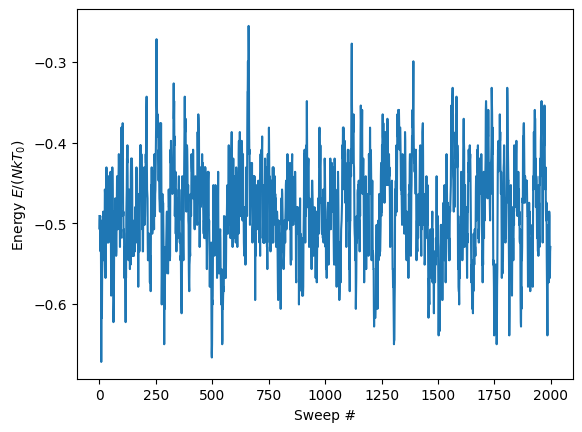

In [16]:
plt.plot(energies)
plt.xlabel('Sweep #')
plt.ylabel(r'Energy $E / (NkT_0)$')

Look at a histogram of the energy and magnetisation measurements and determine the mean and standard error.

Text(0, 0.5, 'Frequency')

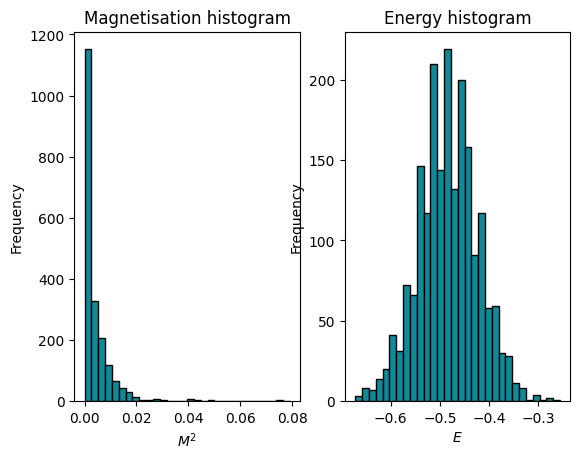

In [17]:
fig, ax = plt.subplots(1,2)
ax[0].hist(mags, bins=30, color='#108A99', edgecolor="black")
ax[0].set_title("Magnetisation histogram")
ax[0].set_xlabel(r"$M^2$")
ax[0].set_ylabel("Frequency")
ax[1].hist(energies, bins=30, color='#108A99', edgecolor="black")
ax[1].set_title("Energy histogram")
ax[1].set_xlabel(r"$E$")
ax[1].set_ylabel("Frequency")

The mean and standard deviation of energy values.

In [21]:
from scipy import stats
statistics = stats.describe(energies)
E_ave = statistics.mean
E_se = stats.sem(energies)
print(f"The average energy is {E_ave:0.3f} with a naive (assuming uncorrelated samples) standard error {E_se:0.3f}")


The average energy is 0.001 with a naive (assuming uncorrelated samples) standard error 0.001


The standard error of the mean above is assuming that we have uncorrelated samples. However, for a markov chain there is some correlation present in moving from one configuration to the next. We need to determine the integrated autocorrelation time $\tau$, the time (or number of steps) it takes for the samples to be uncorrelated or the time taken for the chain to forget where it started. We can then determine the effective sample size $N_{eff} = N/\tau$ and use this to calculate the standard error of the mean:
$$
\sigma_E = {\sigma}/{\sqrt{N_\text{eff}}} = \sqrt{{\text{Var}}/{N_\text{eff}}}
$$

There is a package `emcee` which calculates the auto correlation and integrated time for you. 

In [22]:
import emcee

tau = emcee.autocorr.integrated_time(energies)[0]
n_eff = len(energies) / tau
E_sem_corr = (statistics.variance / n_eff ) ** (1/2)

print(f"The integrated autocorrelation time is {tau:0.3f}, which gives an effective sample size of {n_eff:0.3f}.")
print(f"The resulting correlated standard error in the mean energy is {E_sem_corr:0.3f}")

The integrated autocorrelation time is 0.975, which gives an effective sample size of 10255.682.
The resulting correlated standard error in the mean energy is 0.001


In [23]:
statistics = stats.describe(mags)
m_ave = statistics.mean
tau = emcee.autocorr.integrated_time(mags)[0]
n_eff = len(mags) / tau
m_sem_corr = (statistics.variance / n_eff ) ** (1/2)
print(f"The average magnetisation squared is {m_ave:0.5f} with a standard error {m_sem_corr:0.5f}")

The average magnetisation squared is 0.00136 with a standard error 0.00002


## Measurements at various temperatures
Above we successfully measured energy at a single temperature using our Markov chain Monte Carlo algorithm. Now we want to measure observables for a range of temperatures $\beta J \in [0, 1]$ and $\beta = \infty$. 
This will include calculating:
- Snapshots of the system
- A histogram of the the probability distribution
- The expectation value $< O >$ with the standard error

First define functions for getting the histogram, snapshots and calculating the average value of an observable and its correlated standard error.

In [15]:
def measure_observable(observable_dist, calculate_sem=True):
    '''
    Calculates the expectation value and correlated standard error from a given list of measurements.
    '''
    statistics = stats.describe(observable_dist)
    average = statistics.mean
    if calculate_sem==True:
        if statistics.variance < 0.5: # for small variance distributions the autocorrelation calculation fails (autocorrelation time is too large)
            sem = (statistics.variance / len(observable_dist) ) * (1/2)
            return average, sem
        else:
            tau = emcee.autocorr.integrated_time(observable_dist)[0]
            n_eff = len(observable_dist) / tau
            sem_corr = (statistics.variance / n_eff ) ** (1/2)
            return average, sem_corr
    else:
        return average

In [16]:
def get_hist(observable_dist, L, observable, T, save_hist=True):
    fig, ax = plt.subplots()
    ax.hist(observable_dist, color="#24A2B3", edgecolor="black")
    ax.set_title(f"{observable} for T/T_c = {T:0.3f}")
    ax.set_xlabel("Values")
    ax.set_ylabel("Frequency")
    if save_hist==True:
        filename = f"./histograms/{L}x{L}_{observable}_T_over_Tc_{T:0.3f}.png"
        fig.savefig(filename, dpi=200)

    return fig, ax

Let us check the observables for the specific temperatures we know the answer for. 

For $T=0$ or $\beta = \infty$, the system should be in a ferromagnetic state with magnetisation of 1 and the expected energy should be $-2NkT_0$ where N is the number of spins. This can be generalised as $E = z/2NkT_0$ where $z$ is the number of nearest neighbours, see [Richard Fitzpatrick notes](https://farside.ph.utexas.edu/teaching/329/lectures/node110.html). So we expect the energy to be $-2$ in units of $NkT_0$. In terms of what the probability distribution should look like the Boltzmann distribution gives $e^{-E/kT} = 1$. That is each microstate should have the same probability of occurring and there are $2^N$ possible configurations so the probability is $1/2^N$.

For $T=\infty$ or $\beta = 0$, the system is in complete disorder and we expect a net magnetisation of 0 and the energy to be zero because the spin interactions all cancel in complete disorder.

Energy of the system at T=1e-06 is -1.9992213991769545
Magnetisation squared of the system at T=1e-06 is 0.9974743311110735


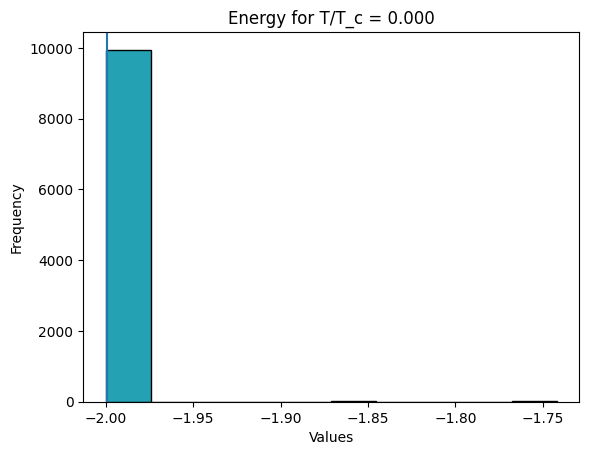

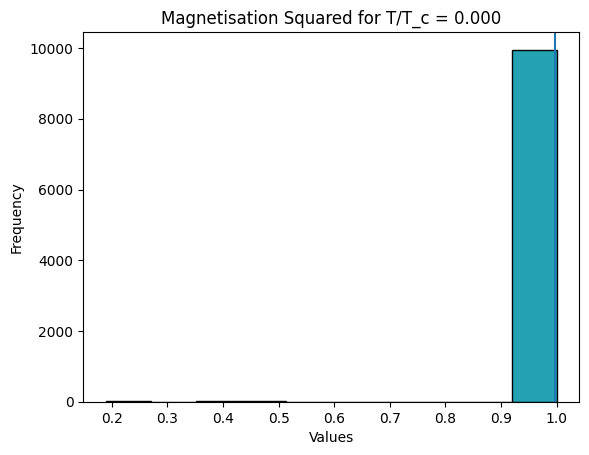

In [16]:
num_sweeps = 10000
N = 1000
L = 27
T = 1e-6


snapshots, energies, mags = runMarkovChainMonteCarlo(T, height=L, width=L, N=N, num_sweeps=num_sweeps, output_prog=False, output_gif=False)
E_ave, E_sem = measure_observable(energies, calculate_sem=True)
mag_ave, mag_sem = measure_observable(mags, calculate_sem=True)
print(f'Energy of the system at T={T} is {E_ave}')
print(f'Magnetisation squared of the system at T={T} is {mag_ave}')
energy_hist = get_hist(energies, L, "Energy", T)
energy_hist[1].axvline(E_ave)
mag_hist = get_hist(mags, L, "Magnetisation Squared", T)
mag_hist[1].axvline(mag_ave)

Energy of the system at T=1000000.0 is -0.0007363511659807956
Magnetisation squared of the system at T=1000000.0 is 0.0013554618480696823


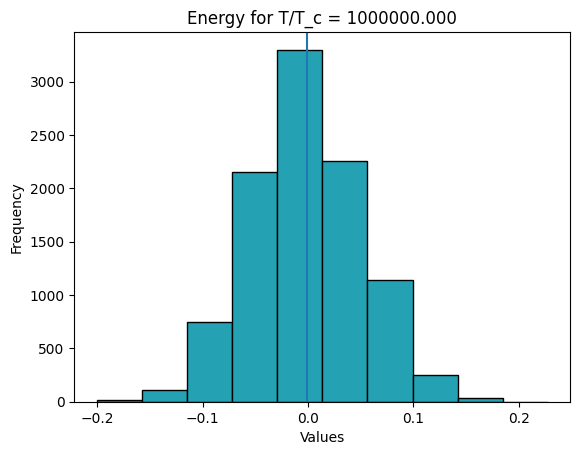

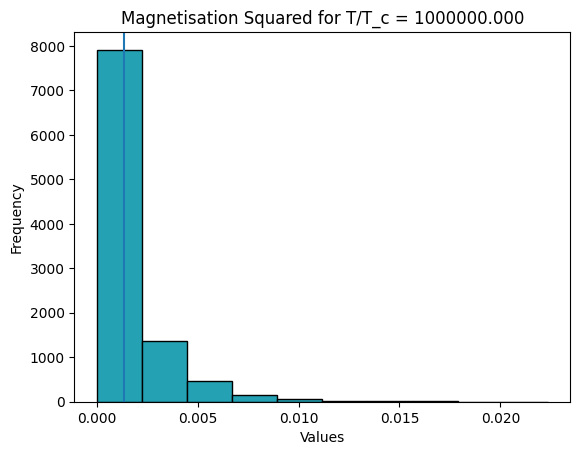

In [24]:
num_sweeps = 10000
N = 1000 # must be large to reduce the auto correlation time between observable measurements
L = 27
T = 1e6


snapshots, energies, mags = runMarkovChainMonteCarlo(T, height=L, width=L, N=N, num_sweeps=num_sweeps, output_prog=False, output_gif=False)
E_ave, E_sem = measure_observable(energies, calculate_sem=True)
mag_ave, mag_sem = measure_observable(mags, calculate_sem=True)
print(f'Energy of the system at T={T} is {E_ave}')
print(f'Magnetisation squared of the system at T={T} is {mag_ave}')
energy_hist = get_hist(energies, L, "Energy", T)
energy_hist[1].axvline(E_ave)
mag_hist = get_hist(mags, L, "Magnetisation Squared", T)
mag_hist[1].axvline(mag_ave)


The results are correct for the extremes of temperature. Now let us create a function that runs the Markov Chain for different temperatures, returns an array of measured observables and plots them versus temperature.

We will add in a calculation of the specific heat to more clearly show the critical temperature where the phase changes. The specific heat is given by $C = dE/dT$. We can calculate this multiple ways. One way is to use the thermodynamic relation:
$$
C = \sigma_E^2 / kT^2
$$
using our calculation of the standard error in the mean $\sigma_E$.

In [17]:
def MarkovChainMonteCarloMeasurements(T_array, L=10, N=100, num_sweeps=1000, generate_hists=False, plot_snapshots=False):

    energy_exps = []
    energy_errs = []
    mag_exps = []
    mag_errs = []
    final_snapshots = []
    energy_hist_list = []
    mag_hist_list = []

    if plot_snapshots == True:
        fig_snapshot, ax_snapshot = plt.subplots(1,len(T_array), figsize=(20,10))

    for i, t in enumerate(T_array):
        snapshots, energies, mags = runMarkovChainMonteCarlo(t, height=L, width=L, N=N, num_sweeps=num_sweeps, output_prog=False, output_gif=False)
    
        E_ave, E_sem = measure_observable(energies)
        mag_ave, mag_sem = measure_observable(mags)

        energy_exps.append(E_ave)
        energy_errs.append(E_sem)
        mag_exps.append(mag_ave)
        mag_errs.append(mag_sem)

        if generate_hists==True:
            energy_hist_list.append(get_hist(energies, L, "Energy", t))
            mag_hist_list.append(get_hist(mags, L, "Magnetisation Squared", t))

        if plot_snapshots == True:
            final_snapshots.append(snapshots[-1])
            ax_snapshot[i].matshow(snapshots[-1], cmap='gray')
            ax_snapshot[i].set_title(f'T/T_c = {t:0.2f}')

    if plot_snapshots == True:
        snapshot_filename = f"./figures/ising_rand_snapshots_v_T_{L}x{L}.png"
        fig_snapshot.savefig(snapshot_filename, dpi=200)

    fig, ax = plt.subplots()
    ax.errorbar(T_array, mag_exps, yerr=mag_errs, fmt=".", ecolor='red')
    ax.set_xlabel(r"$T/T_c$")
    ax.set_ylabel(r"$M^2 / (\mu N)^2$")
    filename = f"./figures/ising_rand_M2_v_T_{L}x{L}.png"
    fig.savefig(filename)

    fig, ax = plt.subplots()
    ax.errorbar(T_array, energy_exps, yerr=energy_errs, fmt=".", ecolor='red')
    ax.set_xlabel(r"$T/T_c$")
    ax.set_ylabel(r"$E / (NkT_0)$")
    filename = f"./figures/ising_rand_E_v_T_{L}x{L}.png"
    fig.savefig(filename)

    specific_heat = (energy_errs / T_array)**2
    fig, ax = plt.subplots()
    ax.plot(T_array, specific_heat, '.')
    ax.set_xlabel(r"$T/T_c$")
    ax.set_ylabel(r"$C / (NkT_0^2)$")
    filename = f"./figures/ising_rand_C_v_T_{L}x{L}.png"
    fig.savefig(filename)

/var/folders/5w/_g0j34k53zndpmjg4_917wp80000gp/T/ipykernel_1843/3048651453.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


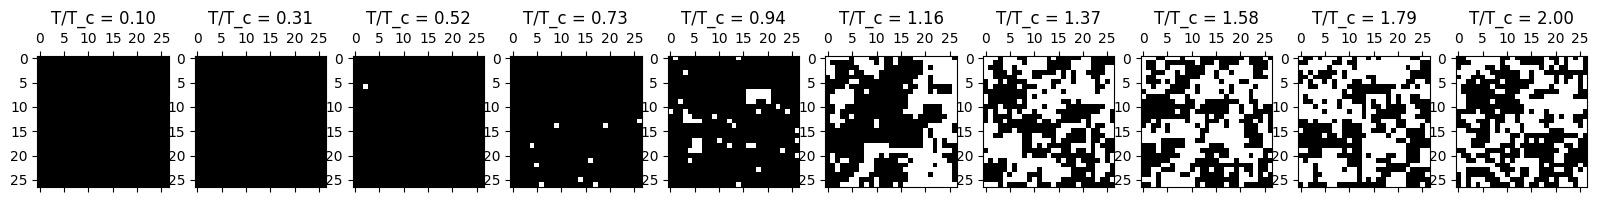

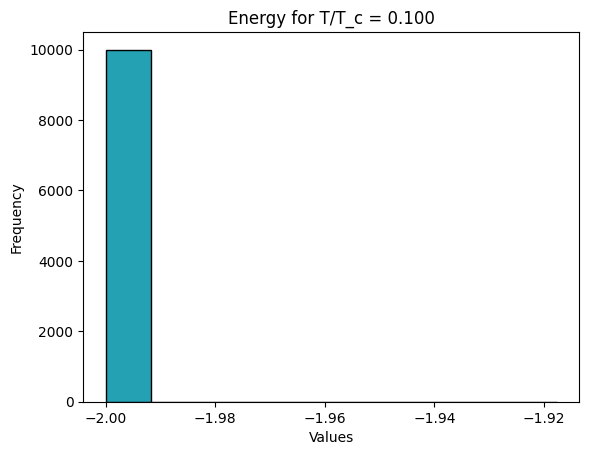

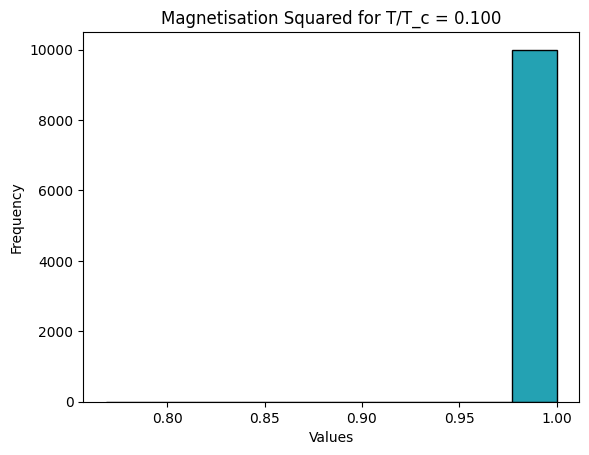

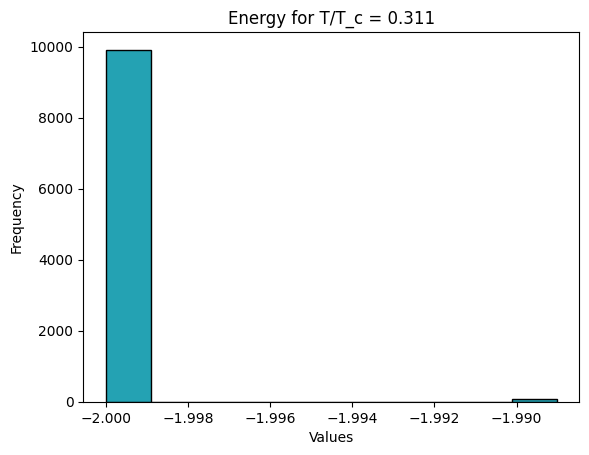

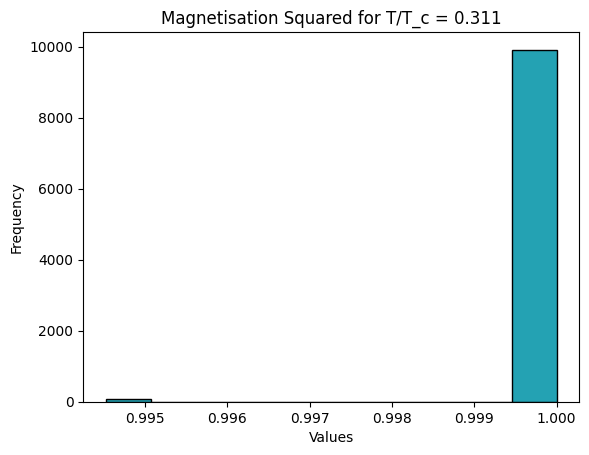

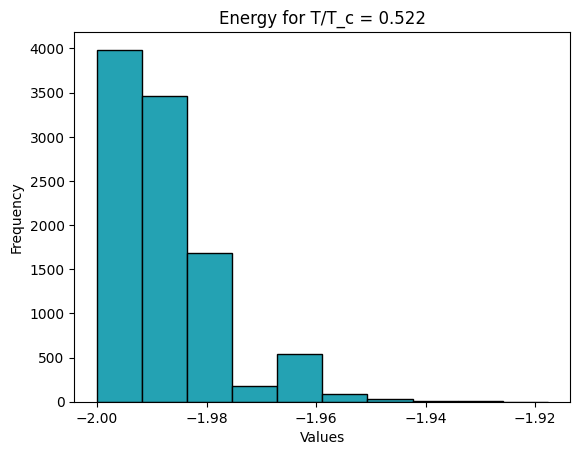

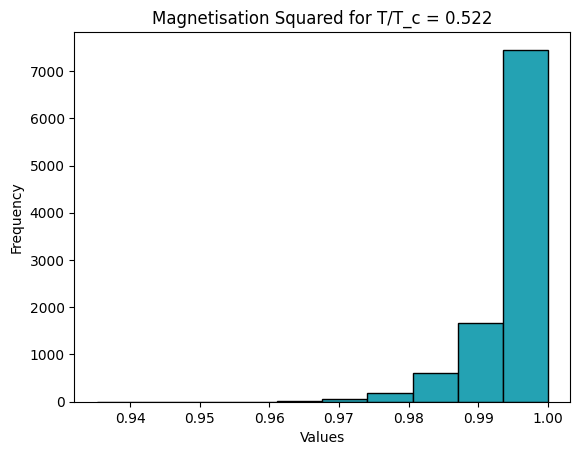

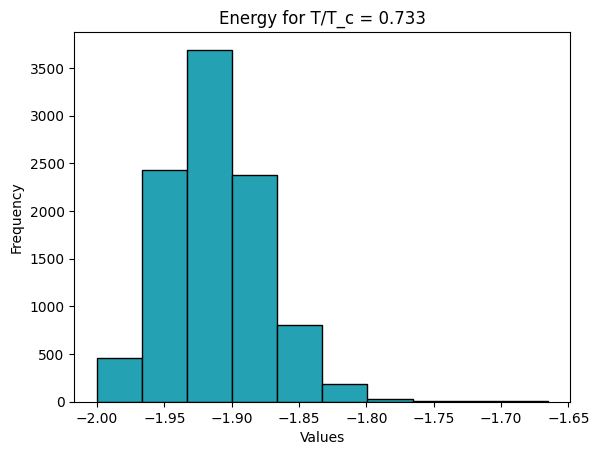

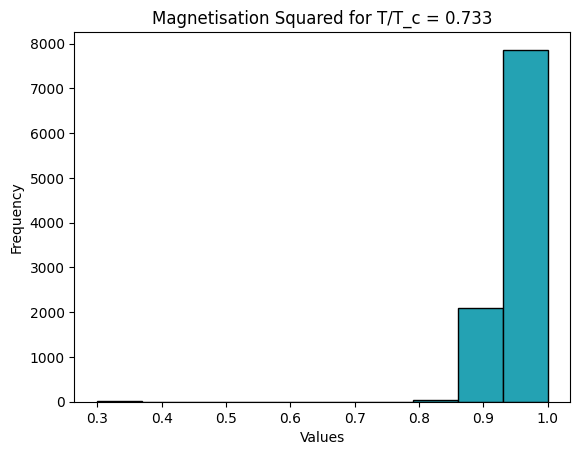

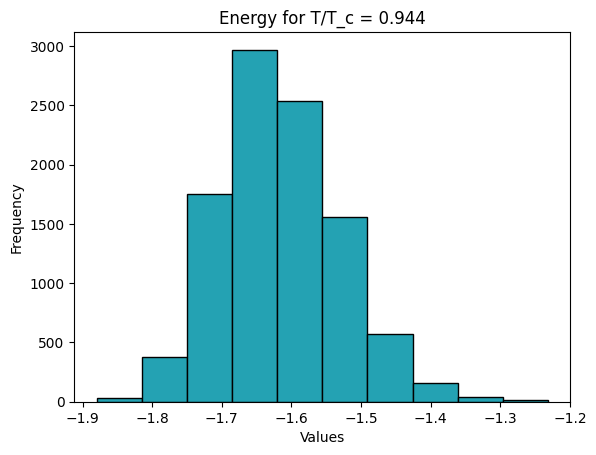

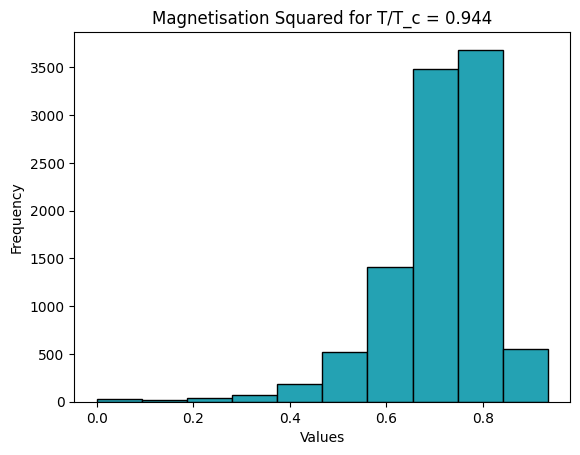

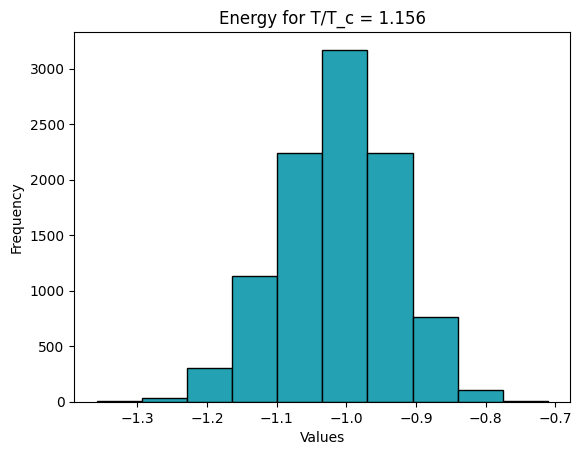

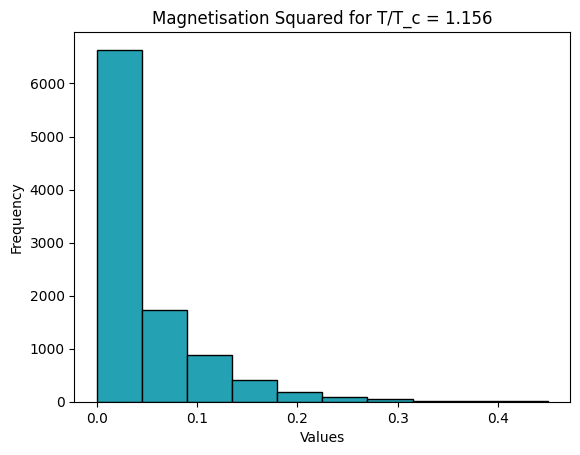

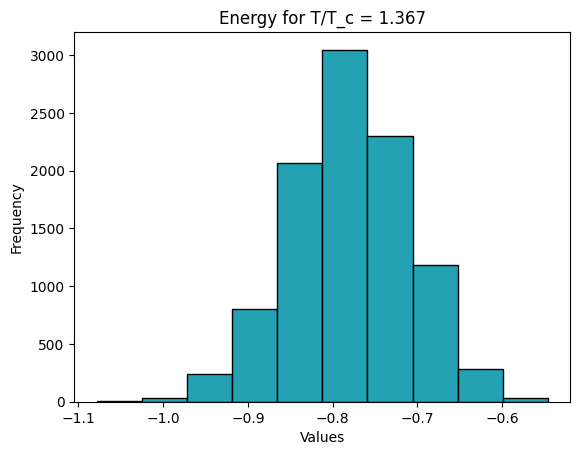

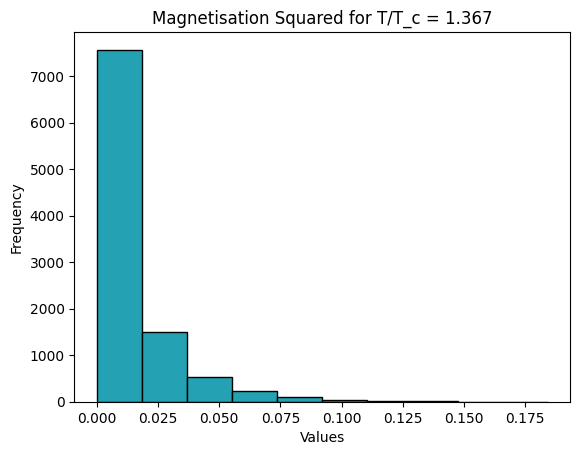

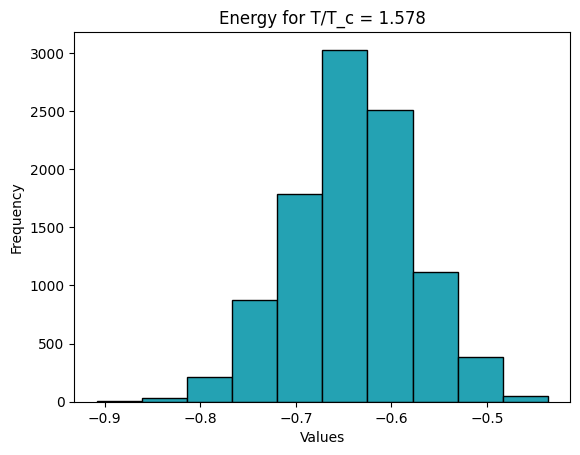

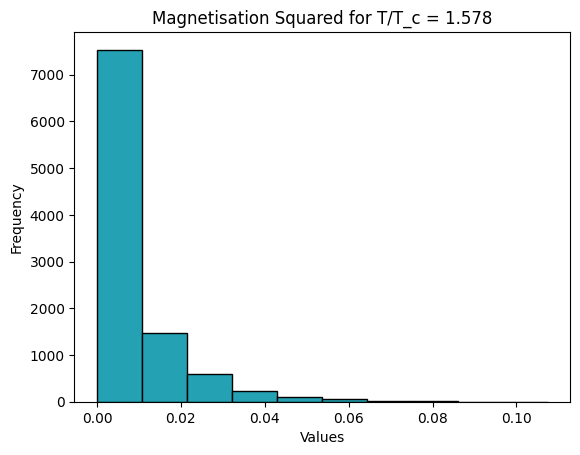

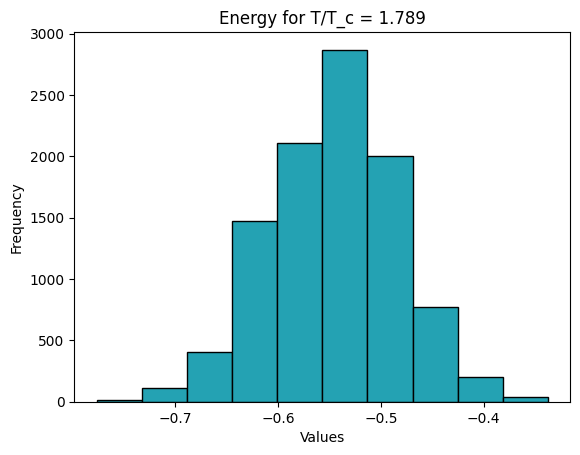

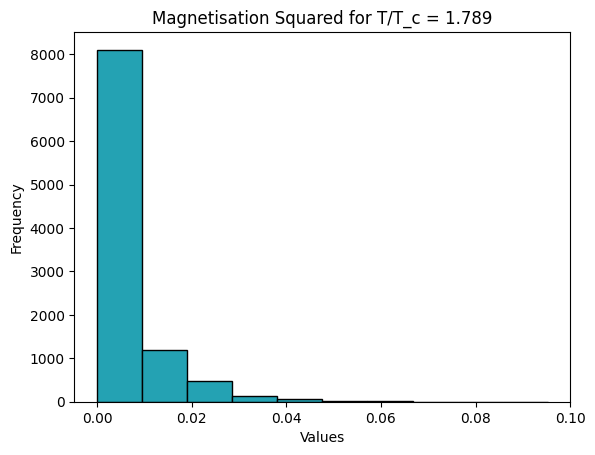

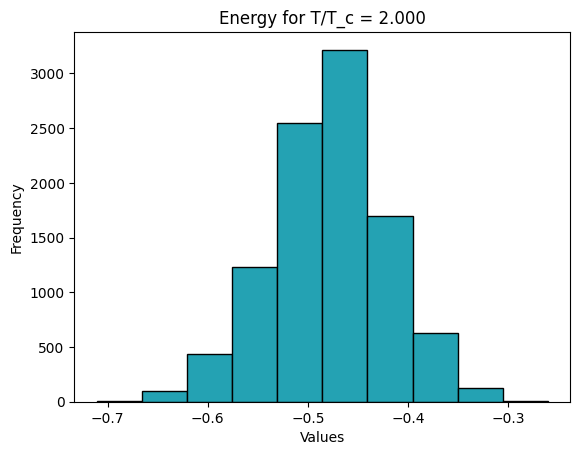

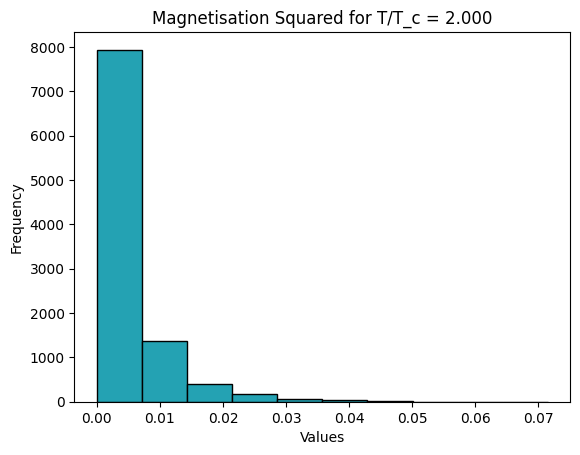

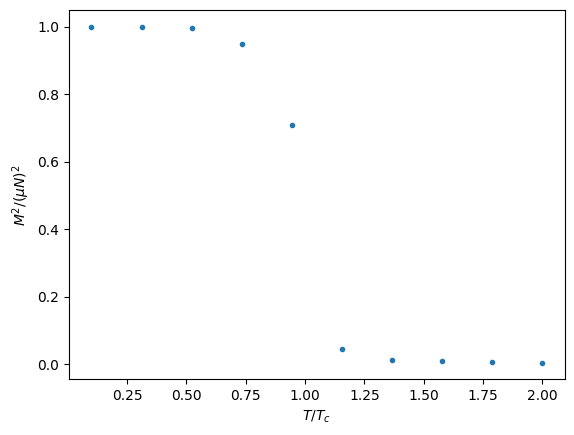

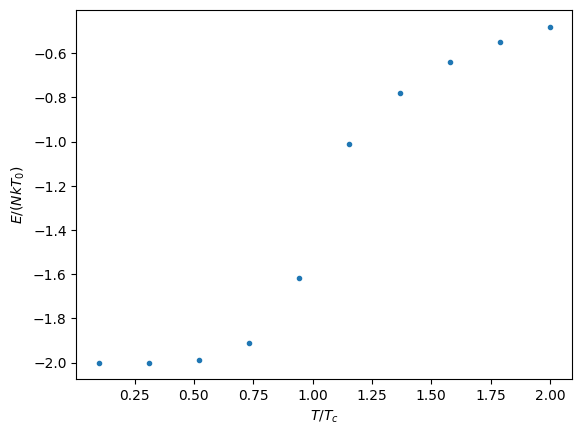

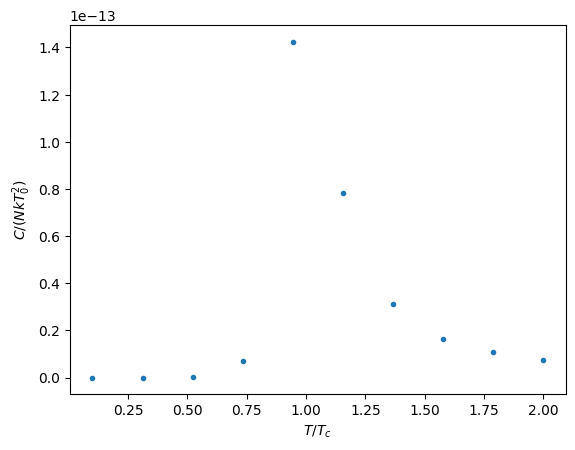

In [31]:
T_array = np.linspace(0.1, 2, 10)
MarkovChainMonteCarloMeasurements(T_array, L=27, N=2500, num_sweeps=10000, generate_hists=True, plot_snapshots=True)

## Speeding up the Markov Chain algorithm
It becomes clear as we increase the size of the lattice grows, the number of sweeps required increases. The code currently does not scale very well. There are multiple options for speeding up the code as mentioned previously including flipping multiple spins at the same time. However, I am going to opt to rewrite the python code in c++ for the Markov Chain section of the algorithm and import it as a module using [pybind11](https://github.com/pybind/pybind11). This is because I want to practice importing C++ code into Python and I would like to keep the current logic of my Markov Chain algorithm as I believe it is simpler to read.

First I import the module that I have made with pybind11.

In [18]:
from IsingMarkovChainMonteCarlo import runIsingMarkovChainCPP

Now we can run the C++ Markov Chain function being careful to use the correct types for the input arguments.

In [19]:
L = int(3)
temperature = float(2.0)
numSteps = int(100)
numSweeps = int(1000)
transientSweeps = int(20)
outputProgress = False
measureComplete = True

energyMeasurements, magSqMeasurements = runIsingMarkovChainCPP(L, temperature, numSteps, numSweeps, transientSweeps, measureComplete, outputProgress)
print(energyMeasurements)
print(magSqMeasurements)

[-2.0, -2.0, -2.0, -2.0, -2.0, -2.0, -2.0, -1.1111111640930176, -2.0, 0.2222222238779068, -2.0, -2.0, -2.0, -2.0, -1.1111111640930176, -2.0, -2.0, -2.0, -1.1111111640930176, -2.0, -2.0, -2.0, -1.1111111640930176, -2.0, -1.1111111640930176, -2.0, -1.1111111640930176, -2.0, -1.1111111640930176, -0.6666666865348816, -2.0, -2.0, -2.0, -1.1111111640930176, -2.0, -2.0, -2.0, -1.1111111640930176, -2.0, -2.0, -2.0, -1.1111111640930176, -2.0, -2.0, -0.2222222238779068, -0.6666666865348816, -2.0, -2.0, -0.6666666865348816, -2.0, -2.0, -1.1111111640930176, -2.0, -2.0, -2.0, -2.0, -2.0, -2.0, -1.1111111640930176, -2.0, -2.0, -2.0, -2.0, -2.0, -2.0, -2.0, -2.0, -2.0, -2.0, -2.0, -1.1111111640930176, -2.0, -2.0, -2.0, -1.1111111640930176, -2.0, -2.0, -1.1111111640930176, -2.0, -2.0, -2.0, -2.0, -2.0, -1.1111111640930176, -1.1111111640930176, -2.0, -2.0, -1.1111111640930176, -0.6666666865348816, -2.0, -2.0, -2.0, -2.0, -0.2222222238779068, -2.0, -2.0, -2.0, -2.0, -1.1111111640930176, -2.0, -2.0, -2.0

Now let us run the markov chain for temperatures T=0 and T=1e6 to check that we get the expected magnetisation and energy.

In [20]:
T= float(0.0)
energyMeasurements, magSqMeasurements = runIsingMarkovChainCPP(L, T, numSteps, numSweeps, transientSweeps, measureComplete, outputProgress)
energies = np.array(energyMeasurements)
mags = np.array(magSqMeasurements)
energyExp = energies.sum() / energies.size
magExp = mags.sum() / energies.size
print(f"The energy and magnetisation for T={T} are {energyExp} and {magExp}, respectively.")

The energy and magnetisation for T=0.0 are -0.6666666865348816 and 0.11111111111111115, respectively.


In [21]:
T= float(1e8)
energyMeasurements, magSqMeasurements = runIsingMarkovChainCPP(L, T, numSteps, numSweeps, transientSweeps, measureComplete, outputProgress)
energies = np.array(energyMeasurements)
mags = np.array(magSqMeasurements)
energyExp = energies.sum() / energies.size
magExp = mags.sum() / energies.size
print(f"The energy and magnetisation for T={T} are {energyExp} and {magExp}, respectively.")

The energy and magnetisation for T=100000000.0 are 0.0168888893276453 and 0.1026172839506173, respectively.


The resulting values are correct as in our previous markov chain algorithm. Now it is obvious from running these that the C++ function is much faster. Lets quickly time and compare.

In [22]:
import time

T = float(1.0)
L = int(27)
numSteps = int(500)
numSweeps = int(10000)
measureComplete = True


start_time = time.perf_counter()
cpp_output = runIsingMarkovChainCPP(L, T, numSteps, numSweeps, transientSweeps, measureComplete, outputProgress)
end_time = time.perf_counter()
cpp_elapsed_time = end_time - start_time

spins = np.random.choice([-1,1], (L, L))
start_time = time.perf_counter()
py_output = markovChainMonteCarlo(spins, T, numSteps, numSweeps, transientSweeps, outputProgress)
end_time = time.perf_counter()
py_elapsed_time = end_time - start_time

print("The elapsed time for cpp code (seconds): ", cpp_elapsed_time)
print("The elapsed time for Python code (seconds): ", py_elapsed_time)

The elapsed time for cpp code (seconds):  12.648033499999656
The elapsed time for Python code (seconds):  19.057644208000056


The C++ code is already slightly faster than the Python code. I will try and optimise it further.

One way to speed up the C++ and the Python code is to stop recalculating the Energy each sweep but rather storing it initially and editing it by the energy difference if it is accepted or rejected. That is if the new spin is flipped
$$
E_\text{new} = \Delta E + E_\text{curr}
$$
but if the new spin flip is rejected keep
$$
E_{new} = E_\text{curr}.
$$
This should take the calculations each step from O(N) to O(1).

We can do the same thing for the magnetisation by initialising it and adding the spin flip if it occurs. The initial magnetisation is (assuming the magnetic moment is $\mu=1$)
$$
M_\text{init} = \frac{1}{N}\sum_i S_i 
$$
If we accept a spin flip at $j$ so that $S_{j} \rightarrow - S_{j}$
$$
M_\text{new} = \frac{1}{N}(\sum_{i\neq j} S_{i} - S_{j}) = \frac{1}{N}(\sum_{i} S_{i} - 2S_{j}) = M_\text{init} -\frac{2}{N}S_{j}
$$
Or more simply the sum of spins changes by $-2S_{j}$ each time a spin flip is accepted at $j$. Otherwise we keep the old magnetisation. 

I added an option in my C++ markov chain algorithm called `measureComplete` which if set to false will use the calculations instead of recalculating the total system energy and magnetisation each time. The result should be an O(1) complexity. 

Let us compare the two C++ algorithm with and without the measureComplete option.

In [26]:
import time

T = float(1.0)
L = int(27)
numSteps = int(500)
numSweeps = int(10000)
measureComplete = True


start_time = time.perf_counter()
cpp_complete_output = runIsingMarkovChainCPP(L, T, numSteps, numSweeps, transientSweeps, measureComplete, outputProgress)
end_time = time.perf_counter()
cpp_complete_elapsed_time = end_time - start_time

measureComplete = False
spins = np.random.choice([-1,1], (L, L))
start_time = time.perf_counter()
cpp_output = runIsingMarkovChainCPP(L, T, numSteps, numSweeps, transientSweeps, measureComplete, outputProgress)
end_time = time.perf_counter()
cpp_elapsed_time = end_time - start_time

print("The elapsed time for cpp code with the complete measurement calculations each step (seconds): ", cpp_complete_elapsed_time)
print("The elapsed time for cpp code without recalculating full system observables each sweep (seconds): ", cpp_elapsed_time)

The elapsed time for cpp code with the complete measurement calculations each step (seconds):  12.33751729200003
The elapsed time for cpp code without recalculating full system observables each sweep (seconds):  6.0684929999999895


The second method is almost two times faster. Let us check the output variables.

In [29]:
energies = np.array(cpp_complete_output[0])
mags = np.array(cpp_complete_output[1])
energyExp = energies.sum() / energies.size
magExp = mags.sum() / energies.size
print(f"The energy and magnetisation for the complete calculation are {energyExp} and {magExp}, respectively.")

The energy and magnetisation for the complete calculation are -1.9943665310382843 and 0.9898770580365459, respectively.


In [30]:
energies = np.array(cpp_output[0])
mags = np.array(cpp_output[1])
energyExp = energies.sum() / energies.size
magExp = mags.sum() / energies.size
print(f"The energy and magnetisation for the complete calculation are {energyExp} and {magExp}, respectively.")

The energy and magnetisation for the complete calculation are -1.9940861454046641 and 0.9879174937575385, respectively.


The results are in agreement. The C++ algorithm is now much faster than the same Python algorithm. Now if we should be able to run the C++ algorithm for different temperatures and produce the plots we created earlier much faster.

In [23]:
def MarkovChainMonteCarloMeasurements(T_array, L=10, N=100, num_sweeps=1000, generate_hists=False, plot_snapshots=False):

    energy_exps = []
    energy_errs = []
    mag_exps = []
    mag_errs = []
    final_snapshots = []
    energy_hist_list = []
    mag_hist_list = []

    # Extra arguments for C++ algorithm
    transientSweeps = int(100)
    measureComplete = False
    outputProgress = False

    Tc = 2.269 # Normalized T:= kT/J = T/T_0
    T = T_array * Tc

    # if plot_snapshots == True:
    #     fig_snapshot, ax_snapshot = plt.subplots(1,len(T_array), figsize=(20,10))

    for i, t in enumerate(T):
        # snapshots, energies, mags = runIsingMarkovChainCPP(t, height=L, width=L, N=N, num_sweeps=num_sweeps, output_prog=False, output_gif=False)
    
        energies, mags = runIsingMarkovChainCPP(int(L), float(t), int(numSteps), int(numSweeps), transientSweeps, measureComplete, outputProgress)

        E_ave, E_sem = measure_observable(energies)
        mag_ave, mag_sem = measure_observable(mags)

        energy_exps.append(E_ave)
        energy_errs.append(E_sem)
        mag_exps.append(mag_ave)
        mag_errs.append(mag_sem)

        if generate_hists==True:
            energy_hist_list.append(get_hist(energies, L, "Energy", t, save_hist=False))
            mag_hist_list.append(get_hist(mags, L, "Magnetisation Squared", t, save_hist=False))

        # if plot_snapshots == True:
        #     final_snapshots.append(snapshots[-1])
        #     ax_snapshot[i].matshow(snapshots[-1], cmap='gray')
        #     ax_snapshot[i].set_title(f'T/T_c = {t:0.2f}')

    # if plot_snapshots == True:
    #     snapshot_filename = f"./figures/ising_rand_snapshots_v_T_{L}x{L}.png"
    #     fig_snapshot.savefig(snapshot_filename, dpi=200)

    fig, ax = plt.subplots()
    ax.errorbar(T_array, mag_exps, yerr=mag_errs, fmt=".", ecolor='red')
    ax.set_xlabel(r"$T/T_c$")
    ax.set_ylabel(r"$M^2 / (\mu N)^2$")
    filename = f"./figures/ising_cpp_M2_v_T_{L}x{L}.png"
    fig.savefig(filename)

    fig, ax = plt.subplots()
    ax.errorbar(T_array, energy_exps, yerr=energy_errs, fmt=".", ecolor='red')
    ax.set_xlabel(r"$T/T_c$")
    ax.set_ylabel(r"$E / (NkT_0)$")
    filename = f"./figures/ising_cpp_E_v_T_{L}x{L}.png"
    fig.savefig(filename)

    specific_heat = (energy_errs / T_array)**2
    fig, ax = plt.subplots()
    ax.plot(T_array, specific_heat, '.')
    ax.set_xlabel(r"$T/T_c$")
    ax.set_ylabel(r"$C / (NkT_0^2)$")
    filename = f"./figures/ising_cpp_C_v_T_{L}x{L}.png"
    fig.savefig(filename)

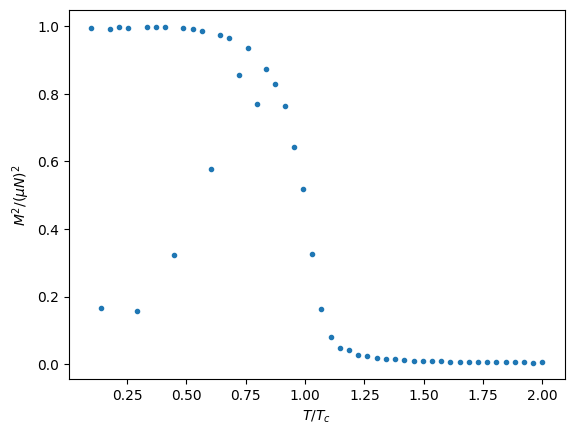

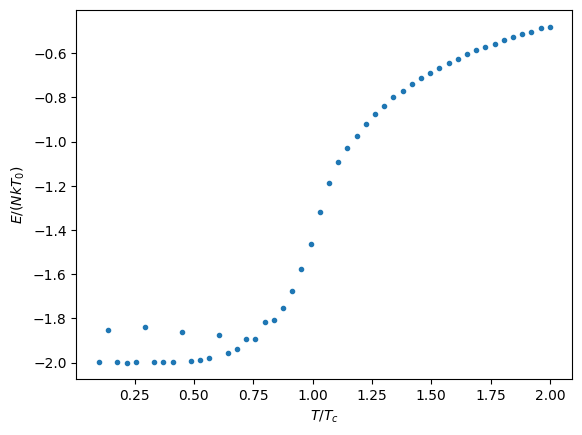

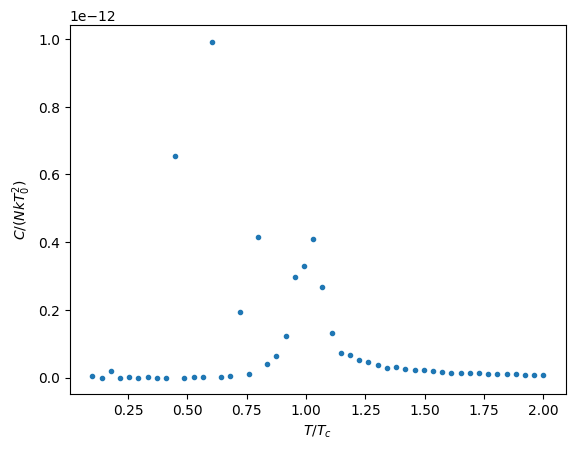

In [24]:
T_array = np.linspace(0.1, 2, 50)
MarkovChainMonteCarloMeasurements(T_array, L=27, N=1000, num_sweeps=10000, generate_hists=False, plot_snapshots=True)

The C++ implementation of the algorithm allows us to calculate the observables for different temperatures much faster than in Python. The only problem is that there are errors in the low temperature case due to the algorithm getting trapped in local minima. The probability distribution rejects changes a lot more and the autocorrelation time increases dramatically. This usually raises an error in our autocorrelation ime but I got around it by avoiding the autocorrelation if the variance is small which suggests a low temperature distribution. 

One way to get better results is to calculate longer chains but this is computationally expensive and less than ideal. Another method one can use is Parallel tempering which allows the system to randomly jump to a configuration that may occur at higher temperatures to avoid getting stuck in local minima.